<a href="https://colab.research.google.com/github/ShaoEH/ai-hw-spring-2026-nn/blob/main/mnist_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [ ]:
mnist_mean = (0.1307,)
mnist_std = (0.3081,)

trainTransform = transforms.Compose([
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

testTransform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mnist_mean, mnist_std)
])

In [ ]:
trainset = torchvision.datasets.MNIST(root='./data', train=True, transform=trainTransform, download=True)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.MNIST(root='./data', train=False, transform=testTransform, download=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.8MB/s]


In [ ]:
class ShallowMLP(nn.Module):
    def __init__(self):
        super(ShallowMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, 3, 1)
        self.conv2 = nn.Conv2d(64, 128, 3, 1)
        self.dropout1 = nn.Dropout(0.3)
        self.fc1 = nn.Linear(18432, 256)
        self.dropout2 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

In [ ]:
class TransformerEncoderModel(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, num_classes=10):
        super(TransformerEncoderModel, self).__init__()
        self.input_proj = nn.Linear(28, d_model)
        self.pos_encoder = nn.Parameter(torch.randn(1, 28, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=128, batch_first=True, dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = x.squeeze(1)
        x = self.input_proj(x) + self.pos_encoder
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.0001)
criterion = nn.CrossEntropyLoss()

In [ ]:
def train(model, optimizer, criterion, total_rounds=5):
    model.train()
    history = []
    for round_idx in range(total_rounds):
        total_err = 0.0
        for i, (imgs, lbls) in enumerate(trainloader):
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            preds = model(imgs)
            batch_loss = criterion(preds, lbls)

            batch_loss.backward()
            optimizer.step()

            total_err += batch_loss.item()

        avg_err = total_err / len(trainloader)
        history.append(avg_err)
        print(f"Round {round_idx + 1} | Avg Loss: {avg_err:.5f}")
    return history

In [ ]:
def test(model, data_loader):
    model.eval()
    correct_count = 0

    with torch.no_grad():
        for imgs, lbls in data_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)

            scores = model(imgs)
            preds = scores.argmax(dim=1, keepdim=True)

            correct_count += preds.eq(lbls.view_as(preds)).sum().item()

    final_score = 100. * correct_count / len(data_loader.dataset)
    return final_score

In [ ]:
criterion = nn.CrossEntropyLoss()

models = {
    "Shallow MLP": ShallowMLP().to(device),
    "CNN": CNN().to(device),
    "Transformer (Encoder)": TransformerEncoderModel().to(device)
}

histories = {}
accuracies = {}

In [ ]:
for name, model in models.items():
    print(f"\n======================================")
    print(f" Now training: {name}")
    print(f"======================================")

    if name == "Shallow MLP":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    elif name == "CNN":
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
    else:  # Transformer
        optimizer = optim.Adam(model.parameters(), lr=0.0005)

    losses = train(model, optimizer, criterion, total_rounds=5)
    acc = test(model, testloader)

    histories[name] = losses
    accuracies[name] = acc
    print(f"\n[測試集驗證] {name} 最終準確率: {acc:.2f}%")


 Now training: Shallow MLP
Round 1 | Avg Loss: 0.32640
Round 2 | Avg Loss: 0.16212
Round 3 | Avg Loss: 0.12653
Round 4 | Avg Loss: 0.10709
Round 5 | Avg Loss: 0.09916

[測試集驗證] Shallow MLP 最終準確率: 97.80%

 Now training: CNN
Round 1 | Avg Loss: 0.30478
Round 2 | Avg Loss: 0.10802
Round 3 | Avg Loss: 0.08173
Round 4 | Avg Loss: 0.06916
Round 5 | Avg Loss: 0.06080

[測試集驗證] CNN 最終準確率: 99.12%

 Now training: Transformer (Encoder)
Round 1 | Avg Loss: 0.53250
Round 2 | Avg Loss: 0.20871
Round 3 | Avg Loss: 0.16660
Round 4 | Avg Loss: 0.14281
Round 5 | Avg Loss: 0.12930

[測試集驗證] Transformer (Encoder) 最終準確率: 97.43%


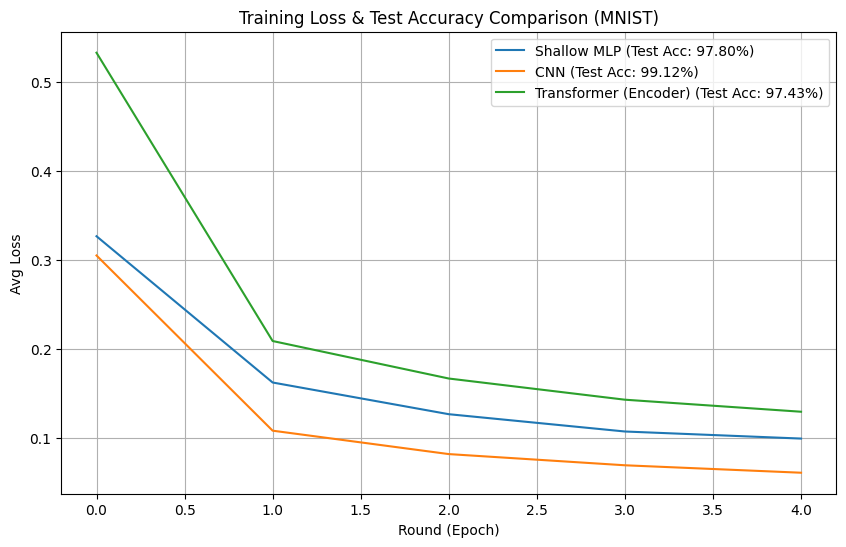

In [ ]:
plt.figure(figsize=(10, 6))
for name, losses in histories.items():
    plt.plot(losses, label=f'{name} (Test Acc: {accuracies[name]:.2f}%)')

plt.title('Training Loss & Test Accuracy Comparison (MNIST)')
plt.xlabel('Round (Epoch)')
plt.ylabel('Avg Loss')
plt.legend()
plt.grid(True)
plt.savefig('mnist_models_comparison.png')
plt.show()